<a href="https://colab.research.google.com/github/ri-ya24/Car-Market-Trends-Analysis/blob/main/Car_Market_Trends_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Car Market Trends Analysis — Minor Project

##  Project Objective
- Used car market ke trends ko samajhna
- Selling price ko affect karne wale factors identify karna
- Depreciation patterns ka analysis karna
- Business insights aur recommendations dena


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [4]:
df = pd.read_csv("/content/1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv")

print(f" Dataset loaded successfully!")
print(f" Shape: {df.shape[0]} rows × {df.shape[1]} columns")


 Dataset loaded successfully!
 Shape: 301 rows × 9 columns


#Dataset Overview & Cleaning


In [5]:

print("=" * 60)
print("📋 DATASET OVERVIEW")
print("=" * 60)

print("\n🔹 First 5 Rows:")
display(df.head())

print("\n🔹 Last 5 Rows:")
display(df.tail())

print("\n🔹 Dataset Shape:", df.shape)

print("\n🔹 Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

print("\n🔹 Data Types:")
print(df.dtypes)

print("\n🔹 Statistical Summary (Numerical):")
display(df.describe())

print("\n🔹 Statistical Summary (Categorical):")
display(df.describe(include='object'))

📋 DATASET OVERVIEW

🔹 First 5 Rows:


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0



🔹 Last 5 Rows:


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0



🔹 Dataset Shape: (301, 9)

🔹 Column Names:
   1. Car_Name
   2. Year
   3. Selling_Price
   4. Present_Price
   5. Kms_Driven
   6. Fuel_Type
   7. Seller_Type
   8. Transmission
   9. Owner

🔹 Data Types:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

🔹 Statistical Summary (Numerical):


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000



🔹 Statistical Summary (Categorical):


,Car_Name,Fuel_Type,Seller_Type,Transmission
count,301,301,301,301
unique,98,3,2,2
top,city,Petrol,Dealer,Manual
freq,26,239,195,261


# Data Quality Check

In [6]:
missing_values = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage.round(2)
})

display(missing_summary)

,Missing Values,Missing Percentage
Car_Name,0,0.0
Year,0,0.0
Selling_Price,0,0.0
Present_Price,0,0.0
Kms_Driven,0,0.0
Fuel_Type,0,0.0
Seller_Type,0,0.0
Transmission,0,0.0
Owner,0,0.0


In [41]:
print("Number of duplicate rows:", df.duplicated().sum())

print("\nAverage Selling Price by Owner Type:")
display(df.groupby('owner')['selling_price'].mean().sort_values(ascending=False))

Number of duplicate rows: 0

Average Selling Price by Owner Type:


,selling_price
owner,
0,4.687847
3,2.500000
1,1.970000


In [8]:
# Remove duplicate records if present
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (299, 9)


In [9]:
dtype_summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str),
    'Unique Values': [df[col].nunique() for col in df.columns]
})

display(dtype_summary)

,Column,Data Type,Unique Values
Car_Name,Car_Name,object,98
Year,Year,int64,16
Selling_Price,Selling_Price,float64,156
Present_Price,Present_Price,float64,147
Kms_Driven,Kms_Driven,int64,206
Fuel_Type,Fuel_Type,object,3
Seller_Type,Seller_Type,object,2
Transmission,Transmission,object,2
Owner,Owner,int64,3


In [10]:
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False))


Car_Name
Car_Name
city                  26
corolla altis         16
verna                 14
brio                  10
fortuner              10
                      ..
Honda Activa 125       1
Hero Hunk              1
Hero  Ignitor Disc     1
Hero  CBZ Xtreme       1
Bajaj  ct 100          1
Name: count, Length: 98, dtype: int64

Fuel_Type
Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

Seller_Type
Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64

Transmission
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64


In [11]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

print(df.columns.tolist())

['car_name', 'year', 'selling_price', 'present_price', 'kms_driven', 'fuel_type', 'seller_type', 'transmission', 'owner']


#Feature Engineering


In [13]:
# Current year for calculating vehicle age
current_year = 2026

df['car_age'] = current_year - df['year']

# Absolute price difference
df['price_difference'] = df['present_price'] - df['selling_price']

# Depreciation percentage
df['depreciation_percentage'] = (
    df['price_difference'] / df['present_price']
) * 100

# Avoid division by zero
df['depreciation_percentage'] = df['depreciation_percentage'].replace(
    [np.inf, -np.inf], np.nan
)

display(df.head())

,car_name,year,selling_price,present_price,kms_driven,fuel_type,seller_type,transmission,owner,car_age,price_difference,depreciation_percentage
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12,2.24,40.071556
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13,4.79,50.209644
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9,2.60,26.395939
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15,1.30,31.325301
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12,2.27,33.042213


#New Dataset Summary

In [14]:
print("Final Dataset Shape:", df.shape)

display(df.describe().T)

Final Dataset Shape: (299, 12)


,count,mean,std,min,25%,50%,75%,max
year,299.0,2013.615385,2.896868,2003.000000,2012.0000,2014.000000,2016.000000,2018.000000
selling_price,299.0,4.589632,4.984240,0.100000,0.8500,3.510000,6.000000,35.000000
present_price,299.0,7.541037,8.567887,0.320000,1.2000,6.100000,9.840000,92.600000
kms_driven,299.0,36916.752508,39015.170352,500.000000,15000.0000,32000.000000,48883.500000,500000.000000
owner,299.0,0.043478,0.248720,0.000000,0.0000,0.000000,0.000000,3.000000
car_age,299.0,12.384615,2.896868,8.000000,10.0000,12.000000,14.000000,23.000000
price_difference,299.0,2.951405,4.837450,0.030000,0.3900,1.610000,3.350000,57.600000
depreciation_percentage,299.0,36.621974,20.287451,1.074547,20.9376,34.574468,49.494949,89.464812


##Check Outliers

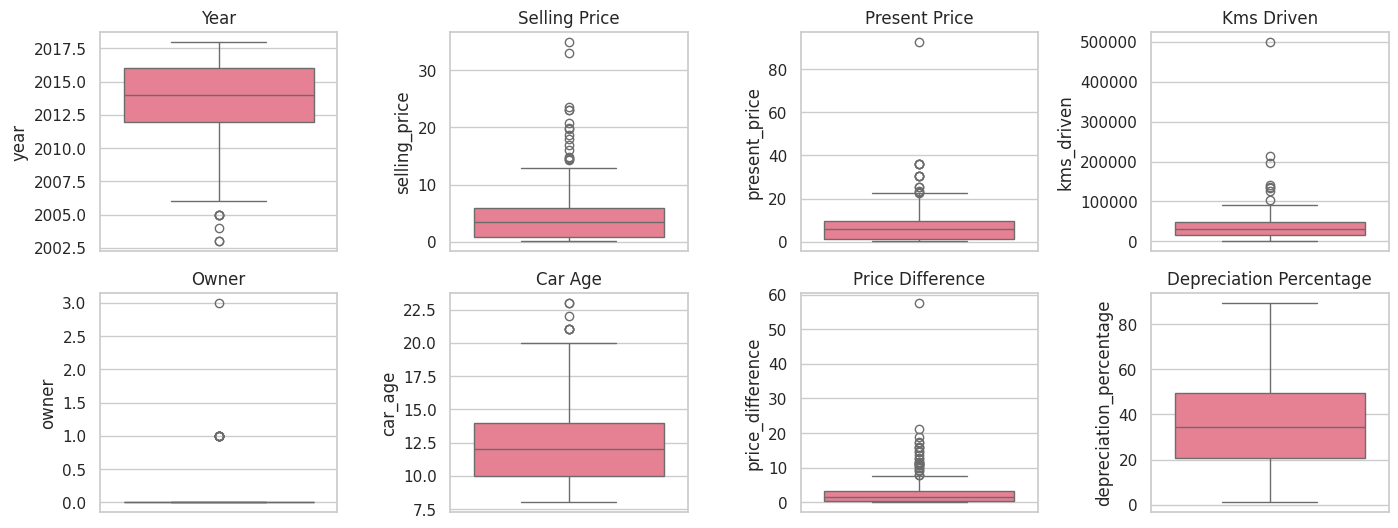

In [15]:
numeric_columns = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(14, 8))

for i, column in enumerate(numeric_columns, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=df[column])
    plt.title(column.replace('_', ' ').title())

plt.tight_layout()
plt.show()

##Selling Price Distribution

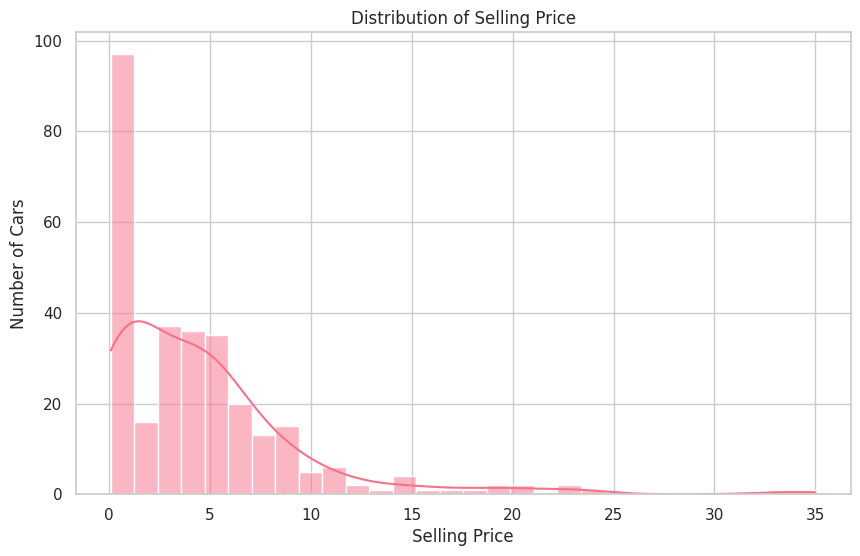

In [16]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='selling_price',
    kde=True,
    bins=30
)

plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')
plt.show()

##Car Age Distribution

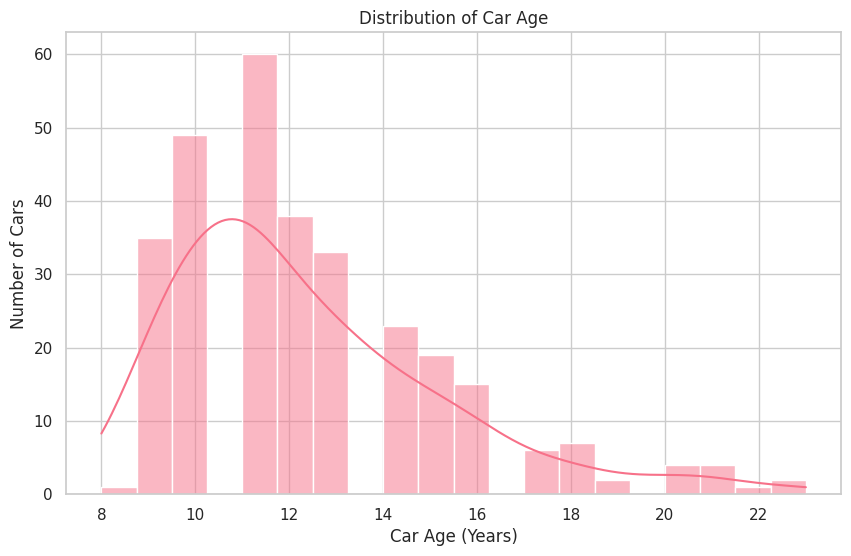

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='car_age',
    kde=True,
    bins=20
)

plt.title('Distribution of Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Number of Cars')
plt.show()

##Fuel Type Distribution

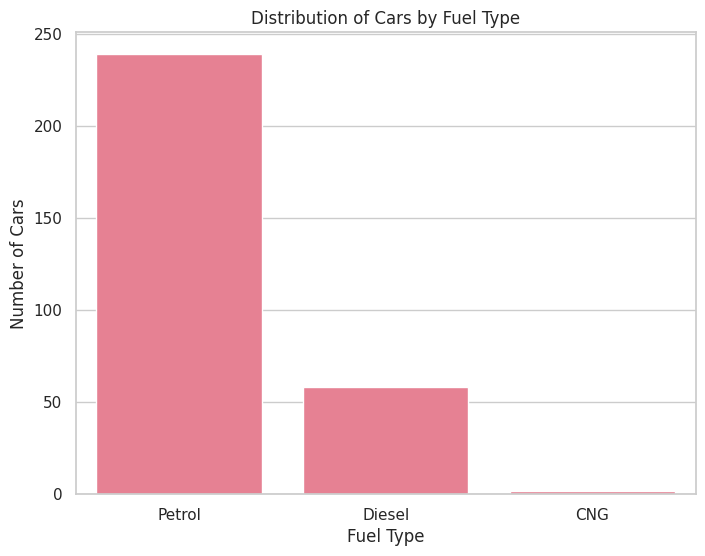

In [18]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x='fuel_type'
)

plt.title('Distribution of Cars by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Cars')
plt.show()

##Seller Type Distribution

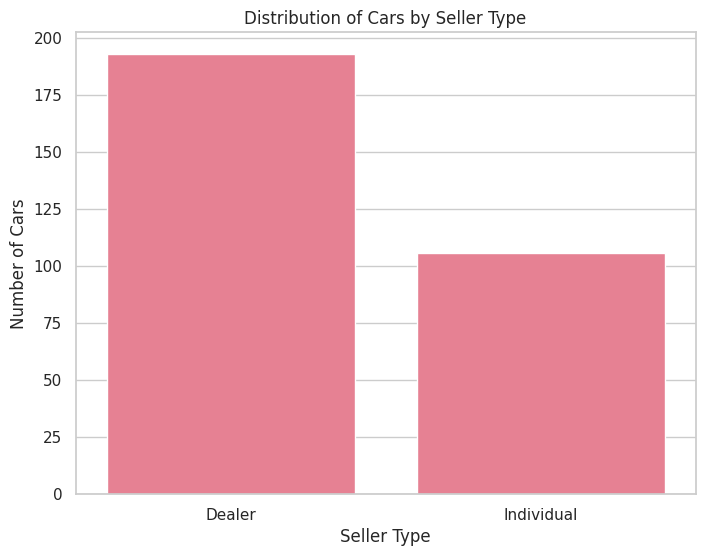

In [19]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x='seller_type'
)

plt.title('Distribution of Cars by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Number of Cars')
plt.show()

##Transmission Distribution

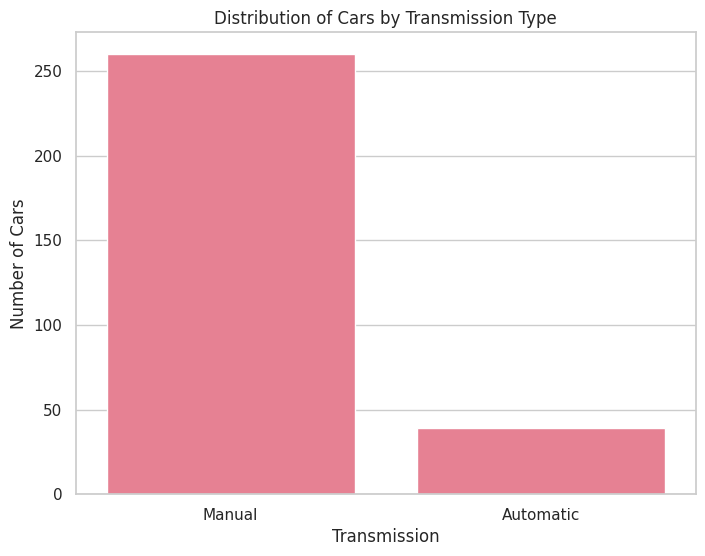

In [20]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x='transmission'
)

plt.title('Distribution of Cars by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Number of Cars')
plt.show()

##Owner Distribution

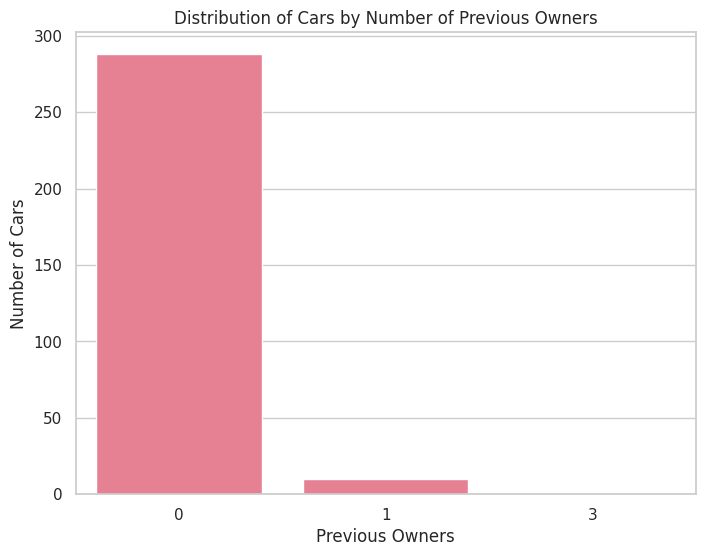

In [21]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x='owner'
)

plt.title('Distribution of Cars by Number of Previous Owners')
plt.xlabel('Previous Owners')
plt.ylabel('Number of Cars')
plt.show()

##Present Price vs Selling Price

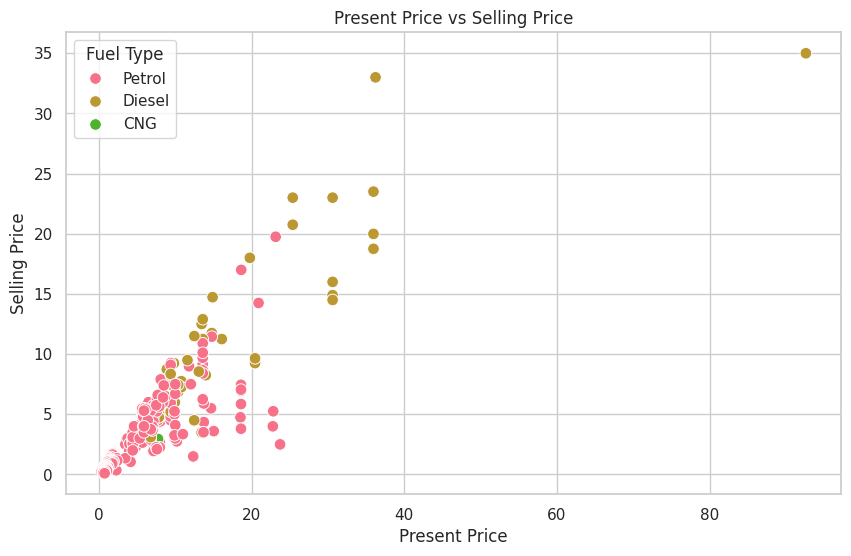

In [22]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='present_price',
    y='selling_price',
    hue='fuel_type',
    s=70
)

plt.title('Present Price vs Selling Price')
plt.xlabel('Present Price')
plt.ylabel('Selling Price')
plt.legend(title='Fuel Type')
plt.show()

##Selling Price vs Car Age

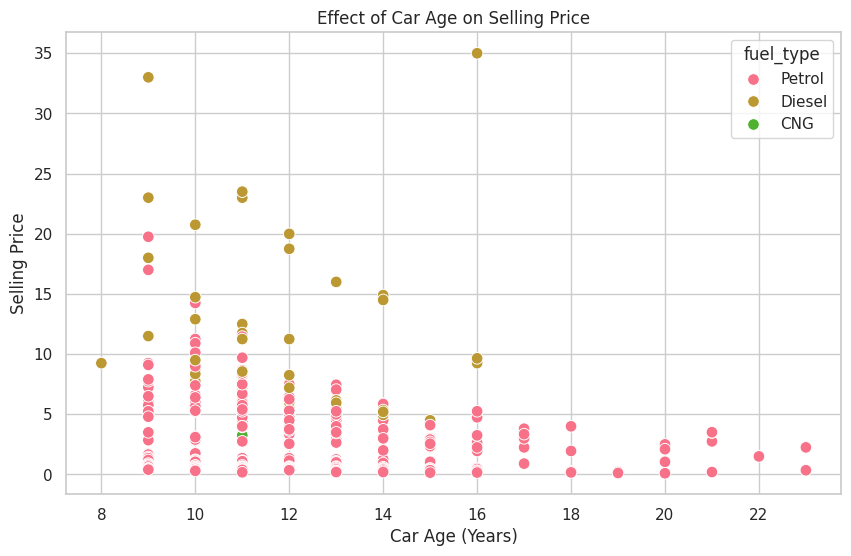

In [23]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='car_age',
    y='selling_price',
    hue='fuel_type',
    s=70
)

plt.title('Effect of Car Age on Selling Price')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price')
plt.show()

##Selling Price vs KMs Driven

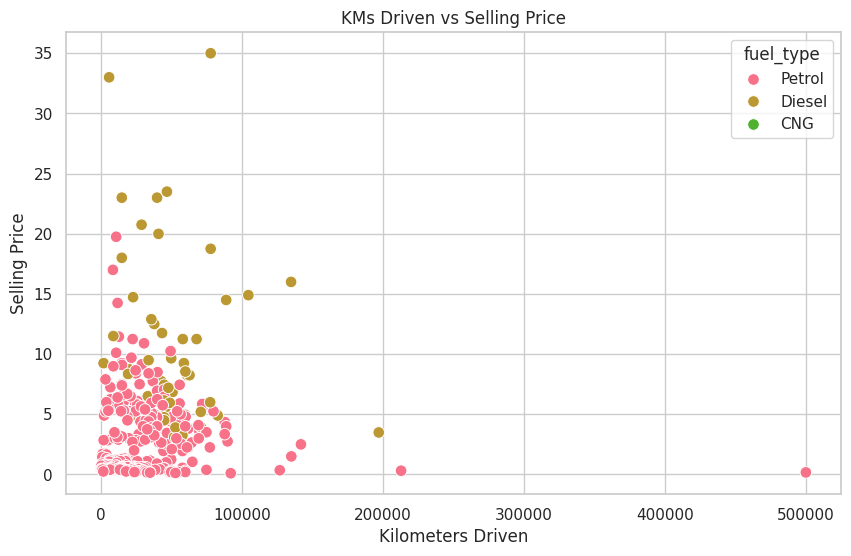

In [24]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='kms_driven',
    y='selling_price',
    hue='fuel_type',
    s=70
)

plt.title('KMs Driven vs Selling Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')
plt.show()

##Average Selling Price by Fuel Type

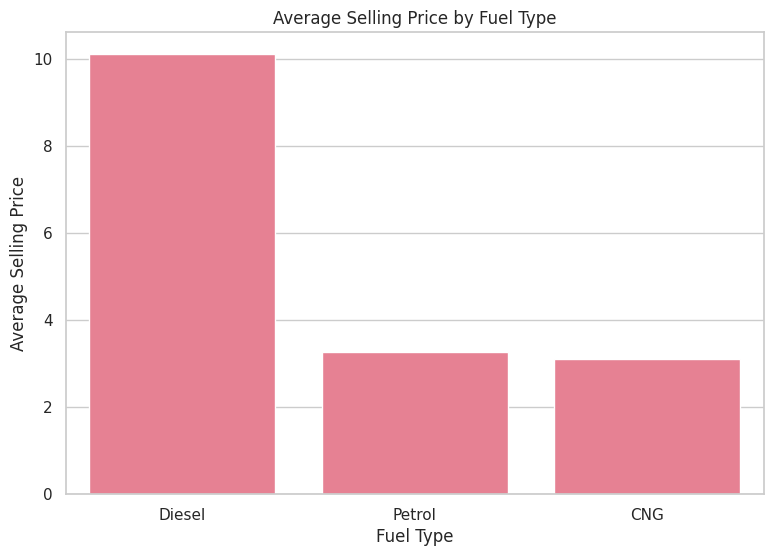

In [25]:
fuel_price = (
    df.groupby('fuel_type')['selling_price']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=fuel_price.index,
    y=fuel_price.values
)

plt.title('Average Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Selling Price')
plt.show()

##Average Selling Price by Seller Type

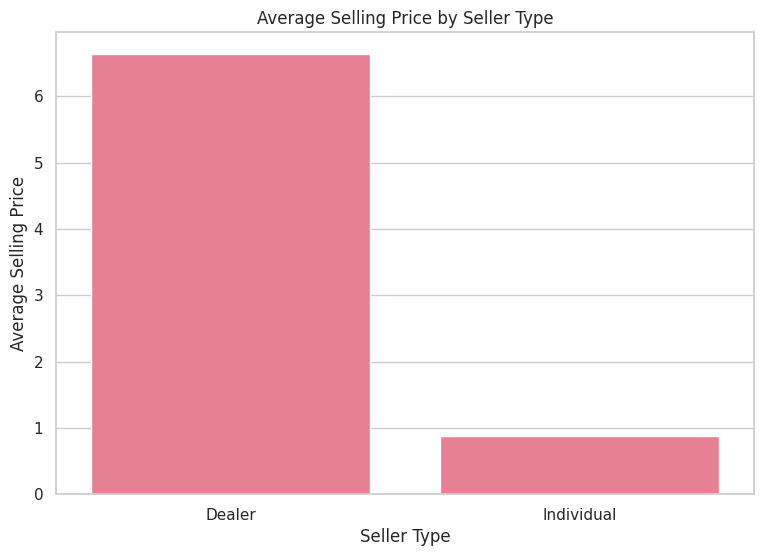

In [26]:
seller_price = (
    df.groupby('seller_type')['selling_price']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=seller_price.index,
    y=seller_price.values
)

plt.title('Average Selling Price by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Average Selling Price')
plt.show()

## Selling Price Distribution by Seller Type

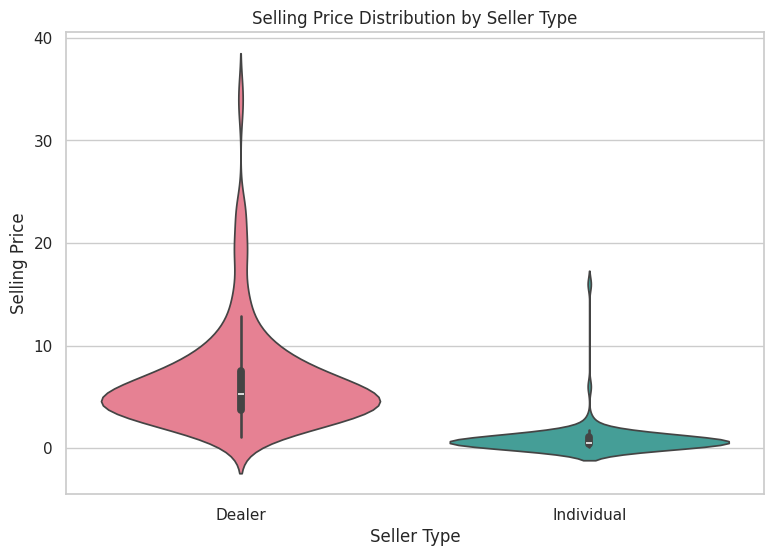

In [44]:
plt.figure(figsize=(9, 6))
sns.violinplot(x='seller_type', y='selling_price', data=df, palette='husl')
plt.title('Selling Price Distribution by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Selling Price')
plt.show()

##Depreciation by Owner Type

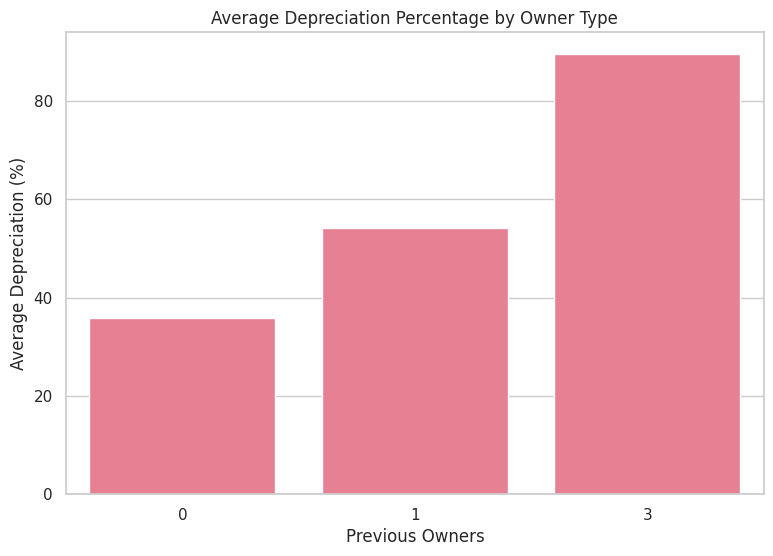

In [42]:
owner_depreciation = (
    df.groupby('owner')['depreciation_percentage']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=owner_depreciation.index,
    y=owner_depreciation.values
)

plt.title('Average Depreciation Percentage by Owner Type')
plt.xlabel('Previous Owners')
plt.ylabel('Average Depreciation (%)')
plt.show()

## Average Selling Price by Car Age and Fuel Type

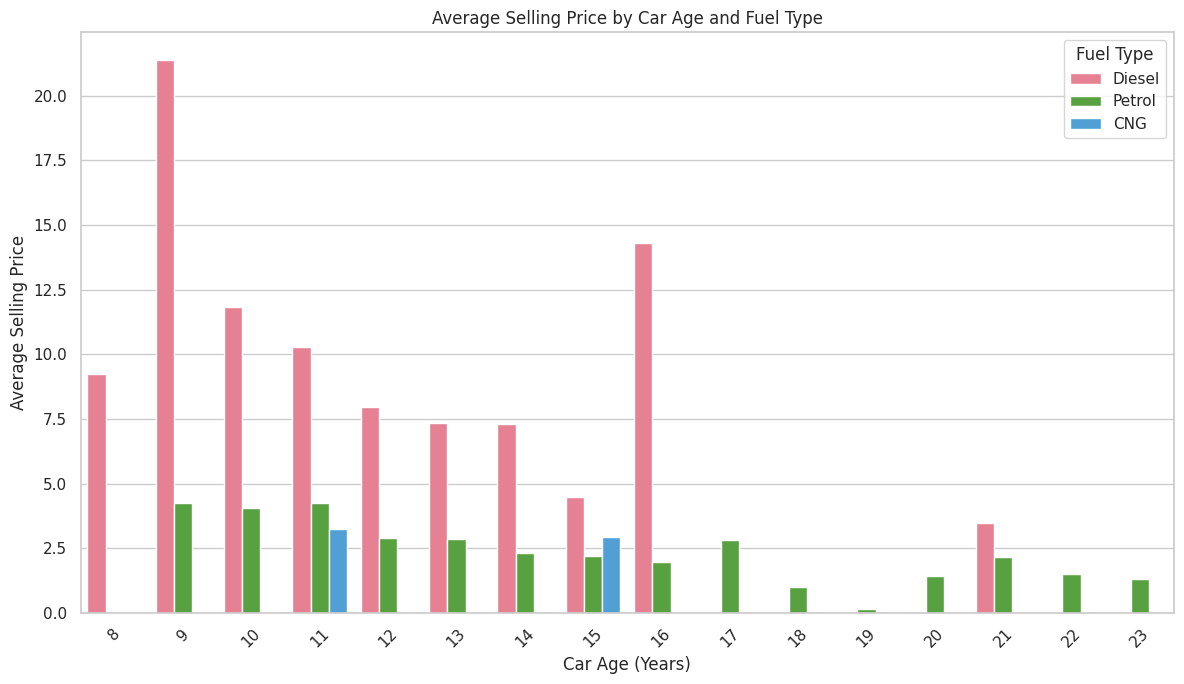

In [43]:
plt.figure(figsize=(12, 7))
sns.barplot(
    data=df.groupby(['car_age', 'fuel_type'])['selling_price'].mean().reset_index(),
    x='car_age',
    y='selling_price',
    hue='fuel_type',
    palette='husl'
)
plt.title('Average Selling Price by Car Age and Fuel Type')
plt.xlabel('Car Age (Years)')
plt.ylabel('Average Selling Price')
plt.xticks(rotation=45)
plt.legend(title='Fuel Type')
plt.tight_layout()
plt.show()

##Average Selling Price by Transmission

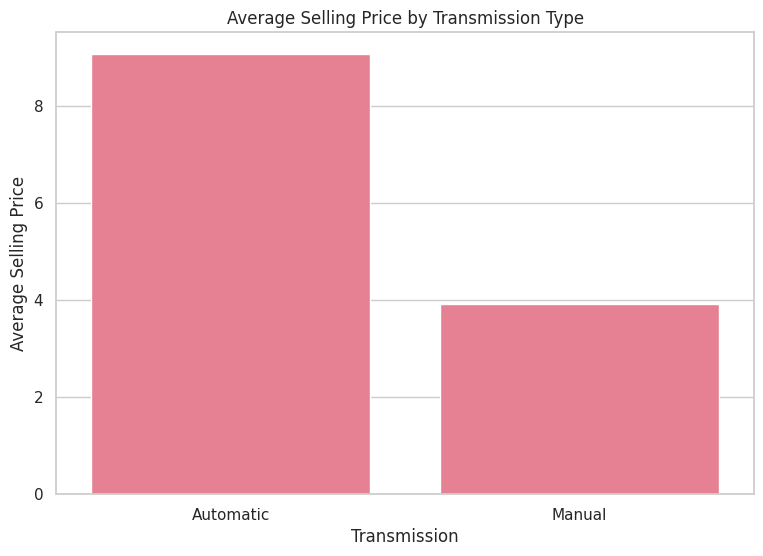

In [27]:
transmission_price = (
    df.groupby('transmission')['selling_price']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=transmission_price.index,
    y=transmission_price.values
)

plt.title('Average Selling Price by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Average Selling Price')
plt.show()

## Selling Price Distribution by Transmission

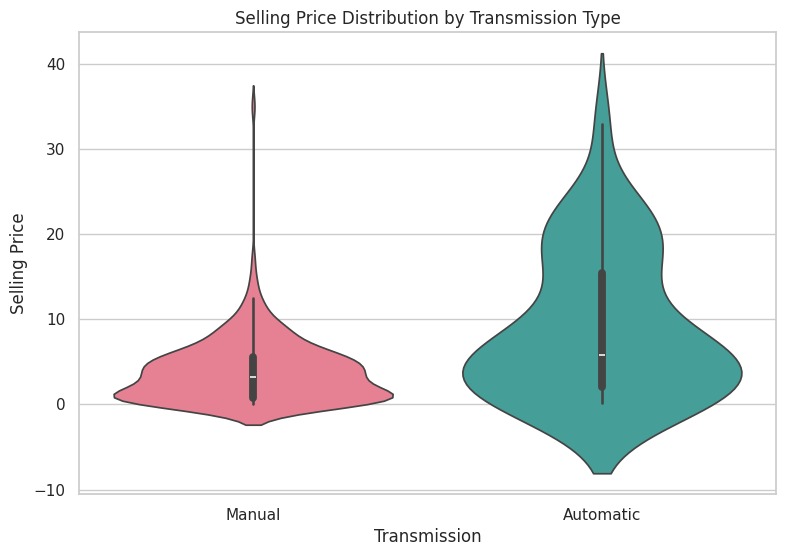

In [45]:
plt.figure(figsize=(9, 6))
sns.violinplot(x='transmission', y='selling_price', data=df, palette='husl')
plt.title('Selling Price Distribution by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Selling Price')
plt.show()

##Depreciation by Fuel Type

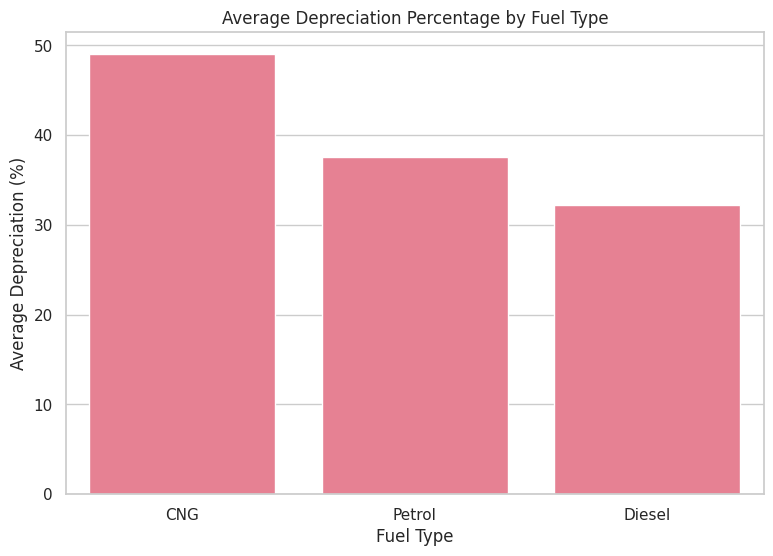

In [28]:
depreciation_fuel = (
    df.groupby('fuel_type')['depreciation_percentage']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=depreciation_fuel.index,
    y=depreciation_fuel.values
)

plt.title('Average Depreciation Percentage by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Depreciation (%)')
plt.show()

##Depreciation by Transmission Type

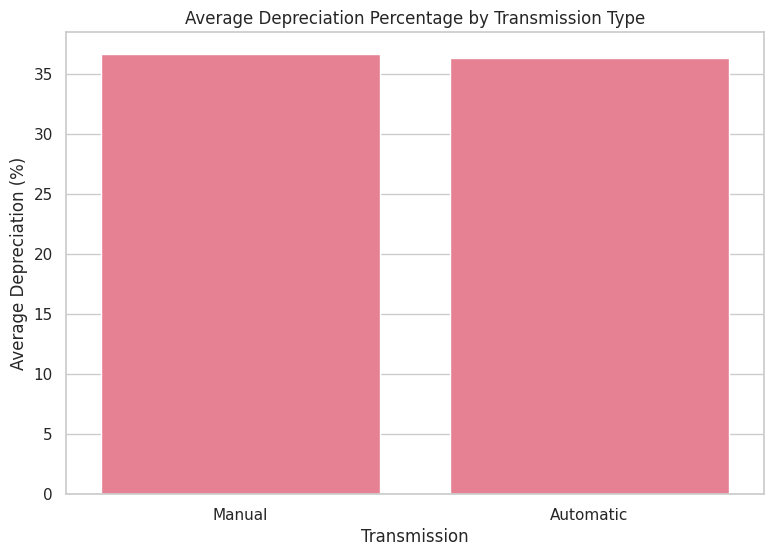

In [47]:
depreciation_transmission = (
    df.groupby('transmission')['depreciation_percentage']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=depreciation_transmission.index,
    y=depreciation_transmission.values
)

plt.title('Average Depreciation Percentage by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Average Depreciation (%)')
plt.show()

##Depreciation by Transmission Type

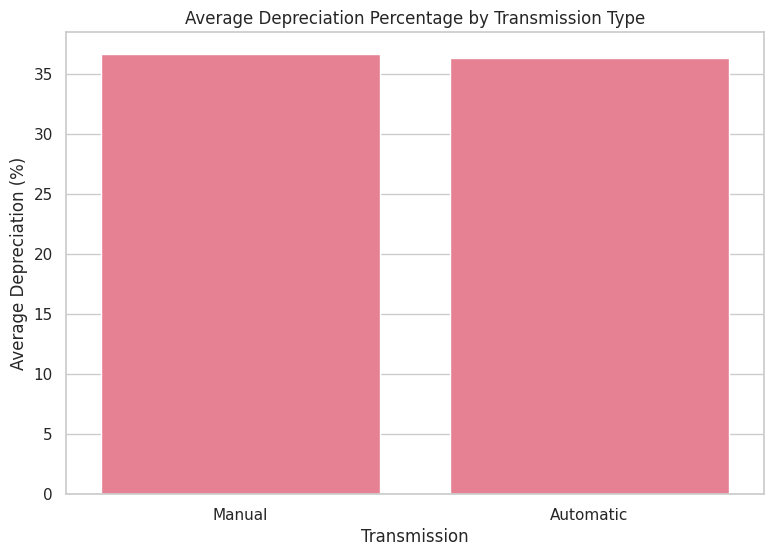

In [46]:
depreciation_transmission = (
    df.groupby('transmission')['depreciation_percentage']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=depreciation_transmission.index,
    y=depreciation_transmission.values
)

plt.title('Average Depreciation Percentage by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Average Depreciation (%)')
plt.show()

##Correlation Matrix

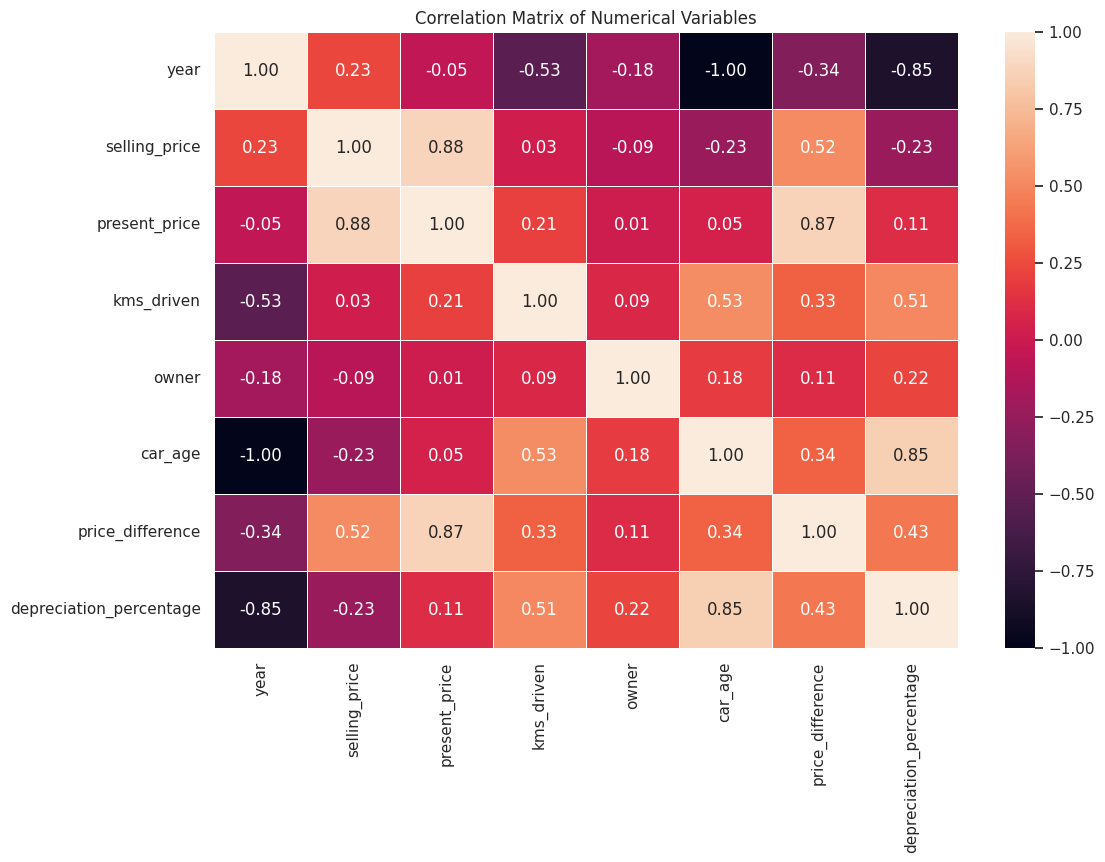

In [29]:
plt.figure(figsize=(12, 8))

correlation_matrix = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

## KMs Driven vs Car Age (with Selling Price)

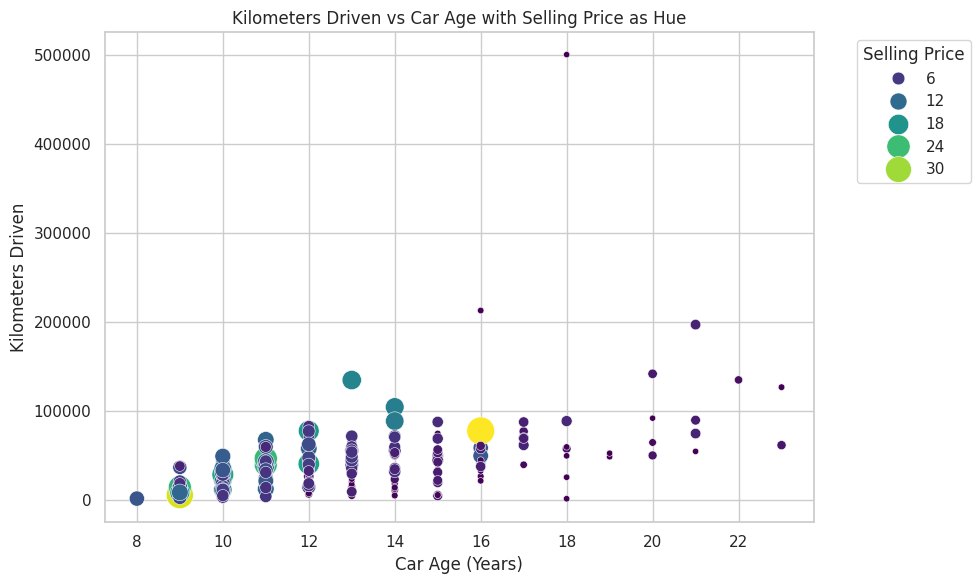

In [48]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='car_age',
    y='kms_driven',
    hue='selling_price',
    size='selling_price',
    sizes=(20, 400),
    palette='viridis'
)
plt.title('Kilometers Driven vs Car Age with Selling Price as Hue')
plt.xlabel('Car Age (Years)')
plt.ylabel('Kilometers Driven')
plt.legend(title='Selling Price', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#Advanced Analysis

##Top 10 Cars by Selling Price

In [31]:
top_10_selling = df.nlargest(10, 'selling_price')

display(
    top_10_selling[
        ['car_name', 'year', 'selling_price', 'present_price',
         'fuel_type', 'transmission']
    ]
)

,car_name,year,selling_price,present_price,fuel_type,transmission
85,land cruiser,2010,35.00,92.60,Diesel,Manual
63,fortuner,2017,33.00,36.23,Diesel,Automatic
62,fortuner,2015,23.50,35.96,Diesel,Automatic
50,fortuner,2015,23.00,30.61,Diesel,Automatic
81,innova,2017,23.00,25.39,Diesel,Automatic
94,innova,2016,20.75,25.39,Diesel,Automatic
58,fortuner,2014,19.99,35.96,Diesel,Automatic
65,innova,2017,19.75,23.15,Petrol,Automatic
61,fortuner,2014,18.75,35.96,Diesel,Automatic
51,innova,2017,18.00,19.77,Diesel,Automatic


##Top 10 Most Expensive Cars by Present Price

In [32]:
top_10_present = df.nlargest(10, 'present_price')

display(
    top_10_present[
        ['car_name', 'year', 'present_price', 'selling_price',
         'fuel_type', 'transmission']
    ]
)

,car_name,year,present_price,selling_price,fuel_type,transmission
85,land cruiser,2010,92.60,35.00,Diesel,Manual
63,fortuner,2017,36.23,33.00,Diesel,Automatic
58,fortuner,2014,35.96,19.99,Diesel,Automatic
61,fortuner,2014,35.96,18.75,Diesel,Automatic
62,fortuner,2015,35.96,23.50,Diesel,Automatic
49,fortuner,2012,30.61,14.90,Diesel,Automatic
50,fortuner,2015,30.61,23.00,Diesel,Automatic
52,fortuner,2013,30.61,16.00,Diesel,Automatic
78,fortuner,2012,30.61,14.50,Diesel,Automatic
81,innova,2017,25.39,23.00,Diesel,Automatic


##Highest Depreciation Cars

In [33]:
top_depreciation = df.nlargest(
    10,
    'depreciation_percentage'
)

display(
    top_depreciation[
        ['car_name', 'year', 'present_price', 'selling_price',
         'depreciation_percentage']
    ]
)

,car_name,year,present_price,selling_price,depreciation_percentage
84,camry,2006,23.73,2.50,89.464812
76,corolla,2004,12.35,1.50,87.854251
198,Bajaj Pulsar 150,2006,0.75,0.10,86.666667
36,800,2003,2.28,0.35,84.649123
92,corolla altis,2008,22.78,4.00,82.440737
89,corolla altis,2009,18.61,3.80,79.580870
197,Honda CB Shine,2007,0.58,0.12,79.310345
77,corolla altis,2010,22.83,5.25,77.003942
54,corolla altis,2009,15.04,3.60,76.063830
46,wagon r,2006,4.15,1.05,74.698795


##Most Common Car Models

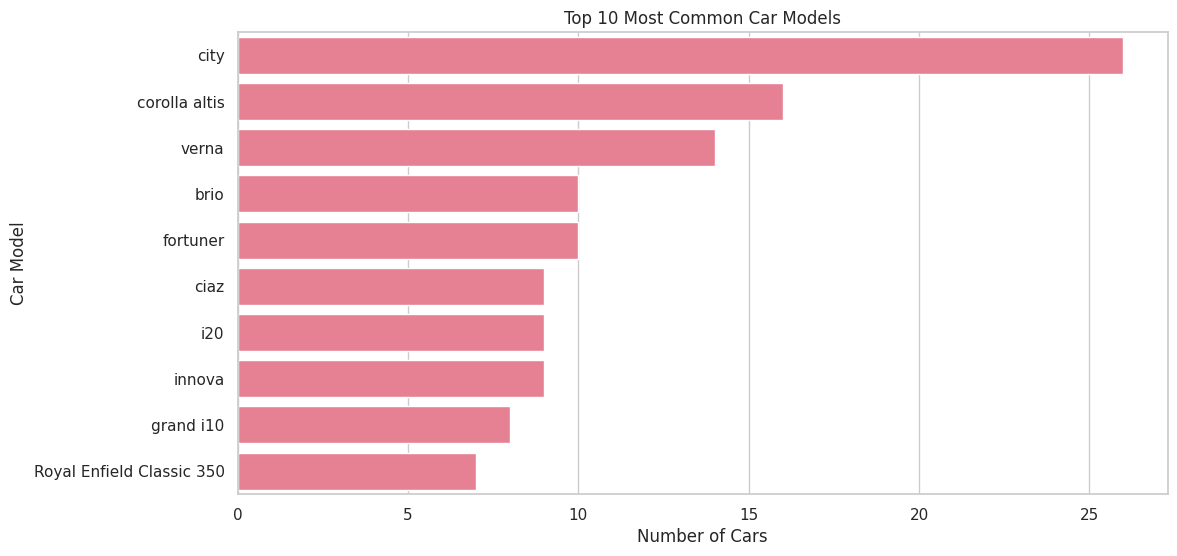

In [34]:
top_models = df['car_name'].value_counts().head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_models.values,
    y=top_models.index
)

plt.title('Top 10 Most Common Car Models')
plt.xlabel('Number of Cars')
plt.ylabel('Car Model')
plt.show()

##Model-wise Average Selling Price

In [35]:
model_analysis = (
    df.groupby('car_name')
    .agg(
        Number_of_Cars=('car_name', 'count'),
        Average_Selling_Price=('selling_price', 'mean'),
        Average_Present_Price=('present_price', 'mean'),
        Average_Depreciation=('depreciation_percentage', 'mean')
    )
    .sort_values('Average_Selling_Price', ascending=False)
)

display(model_analysis.head(15))

,Number_of_Cars,Average_Selling_Price,Average_Present_Price,Average_Depreciation
car_name,,,,
land cruiser,1,35.000000,92.600000,62.203024
fortuner,10,18.254000,30.745000,41.995714
innova,9,12.777778,17.846667,34.450822
creta,3,11.800000,13.600000,13.235294
elantra,2,11.600000,14.790000,21.568627
vitara brezza,1,9.250000,9.830000,5.900305
ciaz,9,7.472222,9.756667,22.487716
city,26,7.419231,11.791923,38.177710
corolla altis,16,7.183125,17.582500,58.523378


#Final Dataset Check

In [36]:
print("FINAL DATASET SUMMARY")
print("-" * 40)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

FINAL DATASET SUMMARY
----------------------------------------
Rows: 299
Columns: 12
Missing Values: 0
Duplicate Rows: 0


In [54]:
# ==========================================
# KEY PERFORMANCE INDICATORS (KPIs)
# ==========================================

kpi_summary = {
    'Total Cars': df.shape[0],
    'Average Selling Price (₹ Lakhs)': df['selling_price'].mean(),
    'Average Present Price (₹ Lakhs)': df['present_price'].mean(),
    'Average Car Age (Years)': df['car_age'].mean(),
    'Average KMs Driven': df['kms_driven'].mean(),
    'Average Depreciation (%)': df['depreciation_percentage'].mean(),
    'Highest Selling Price (₹ Lakhs)': df['selling_price'].max(),
    'Lowest Selling Price (₹ Lakhs)': df['selling_price'].min()
}

kpi_df = pd.DataFrame(
    list(kpi_summary.items()),
    columns=['KPI', 'Value']
)

# Round numerical values for clean presentation
kpi_df['Value'] = kpi_df['Value'].round(2)

display(kpi_df)

,KPI,Value
0,Total Cars,299.00
1,Average Selling Price (₹ Lakhs),4.59
2,Average Present Price (₹ Lakhs),7.54
3,Average Car Age (Years),12.38
4,Average KMs Driven,36916.75
5,Average Depreciation (%),36.62
6,Highest Selling Price (₹ Lakhs),35.00
7,Lowest Selling Price (₹ Lakhs),0.10


# Key Business Insights

> **Note:** The following insights should be interpreted based on the actual analysis, visualizations, and statistical results obtained from the dataset.

### Pricing Insights

1. **Present Price and Selling Price:** The relationship between a car's Present Price and Selling Price should be evaluated using correlation and scatter-plot analysis to understand how strongly the original/current market value influences resale price.
2. **Selling Price Distribution:** Selling prices show considerable variation, ranging from **₹0.10 lakh to ₹35 lakh**, indicating the presence of both budget and premium vehicles.
3. **Price Variation:** The difference between Present Price and Selling Price provides an important indicator of the depreciation experienced by used vehicles.

### Depreciation Insights

4. **Car Age Impact:** Car age is an important factor to examine when evaluating depreciation, as older vehicles generally require greater price adjustment in the used-car market.
5. **Fuel Type:** Differences in average selling price and depreciation across Petrol, Diesel, and CNG vehicles can help identify fuel-type-specific resale patterns.
6. **Transmission:** Comparing Manual and Automatic vehicles helps identify whether transmission type is associated with differences in resale prices.

### Usage Insights

7. **KMs Driven:** The dataset contains vehicles with mileage ranging from **500 km to 500,000 km**. The relationship between KMs Driven and Selling Price can therefore provide useful insights into the effect of vehicle usage on resale value.
8. **Vehicle Usage:** KMs Driven should be considered together with Car Age rather than independently, as two vehicles of the same age may have substantially different usage levels.

### Market Insights

9. **Car Model:** Car-wise analysis can identify the most frequently represented models and compare their average Present Price, Selling Price, and depreciation.
10. **Ownership:** The dataset contains vehicles with different ownership histories. Comparing Selling Price across ownership categories can help determine whether previous ownership is associated with resale value.

---

# Business Recommendations

### For Sellers / Dealers

* Use **Present Price, Car Age, KMs Driven, Fuel Type, Transmission, and Ownership** together when estimating a suitable resale price.
* Highlight **lower usage and favourable ownership history** when these factors are supported by the data.
* Compare a vehicle with similar models before deciding its final selling price.

### For Buyers

* Compare the **Selling Price with Present Price** to understand the level of depreciation.
* Consider **Car Age and KMs Driven together** before evaluating whether a vehicle is fairly priced.
* Check fuel type, transmission, and ownership history along with the asking price before making a purchase decision.

### For Platform / Business

* A **data-driven pricing system** can use Present Price, Car Age, KMs Driven, Fuel Type, Transmission, Ownership, and Car Model as potential pricing factors.
* A depreciation calculator can help users estimate the expected resale value of a vehicle.
* Historical vehicle data can be used to develop a **machine-learning model for Selling Price prediction**.

---

# Conclusion

This analysis of **301 used-car records** provides insights into the factors associated with used-car selling prices.

1. **Present Price, Car Age, and KMs Driven** are important variables for analysing variations in Selling Price.
2. The dataset covers a wide range of vehicle prices, with Selling Price ranging from **₹0.10 lakh to ₹35 lakh**.
3. The difference between Present Price and Selling Price provides a useful measure for analysing **vehicle depreciation**.
4. **Fuel Type, Seller Type, Transmission, and Ownership** can be compared to identify differences in resale-price patterns.
5. The analysis provides a foundation for developing **data-driven pricing strategies and predictive models** for the used-car market.

Overall, the project demonstrates how exploratory data analysis can be used to understand **pricing, depreciation, usage, and market patterns** in the used-car segment.


# Interactive Dashboard

In [59]:
# Install required library for the interactive dashboard
!pip install -q plotly

In [62]:


import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, HTML

# ------------------------------------------------------------
# KPI CALCULATIONS
# ------------------------------------------------------------

total_cars = len(df)
avg_selling_price = df['selling_price'].mean()
avg_present_price = df['present_price'].mean()
avg_car_age = df['car_age'].mean()
avg_kms = df['kms_driven'].mean()
avg_depreciation = df['depreciation_percentage'].mean()

# ------------------------------------------------------------
#  CAR MARKET TRENDS DASHBOARD
# ------------------------------------------------------------

display(HTML("""
<div style="
    background-color:#ffffff;
    padding:28px;
    border-radius:12px;
    text-align:center;
    margin-bottom:20px;
    border:1px solid #d9d9d9;
">
    <h1 style="
        color:#1f2937 !important;
        font-size:30px;
        font-weight:700;
        margin:0 0 8px 0;
    ">
        🚗 Car Market Trends Dashboard
    </h1>

    <p style="
        color:#4b5563 !important;
        font-size:16px;
        margin:0;
    ">
        Used-Car Pricing, Depreciation & Market Analysis
    </p>
</div>
"""))

# ------------------------------------------------------------
# KPI CARDS
# ------------------------------------------------------------

kpi_html = f"""
<div style="
    display:flex;
    gap:15px;
    flex-wrap:wrap;
    margin-bottom:25px;
">

<div style="
    flex:1;
    min-width:180px;
    padding:20px;
    background-color:#ffffff;
    border:1px solid #d9d9d9;
    border-radius:10px;
    text-align:center;
">
    <h3 style="color:#374151 !important; margin:0 0 10px 0;">
        Total Cars
    </h3>
    <h2 style="color:#111827 !important; margin:0; font-size:26px;">
        {total_cars}
    </h2>
</div>

<div style="
    flex:1;
    min-width:180px;
    padding:20px;
    background-color:#ffffff;
    border:1px solid #d9d9d9;
    border-radius:10px;
    text-align:center;
">
    <h3 style="color:#374151 !important; margin:0 0 10px 0;">
        Avg Selling Price
    </h3>
    <h2 style="color:#111827 !important; margin:0; font-size:26px;">
        ₹{avg_selling_price:.2f} L
    </h2>
</div>

<div style="
    flex:1;
    min-width:180px;
    padding:20px;
    background-color:#ffffff;
    border:1px solid #d9d9d9;
    border-radius:10px;
    text-align:center;
">
    <h3 style="color:#374151 !important; margin:0 0 10px 0;">
        Avg Present Price
    </h3>
    <h2 style="color:#111827 !important; margin:0; font-size:26px;">
        ₹{avg_present_price:.2f} L
    </h2>
</div>

<div style="
    flex:1;
    min-width:180px;
    padding:20px;
    background-color:#ffffff;
    border:1px solid #d9d9d9;
    border-radius:10px;
    text-align:center;
">
    <h3 style="color:#374151 !important; margin:0 0 10px 0;">
        Avg Car Age
    </h3>
    <h2 style="color:#111827 !important; margin:0; font-size:26px;">
        {avg_car_age:.1f} Years
    </h2>
</div>

<div style="
    flex:1;
    min-width:180px;
    padding:20px;
    background-color:#ffffff;
    border:1px solid #d9d9d9;
    border-radius:10px;
    text-align:center;
">
    <h3 style="color:#374151 !important; margin:0 0 10px 0;">
        Avg Depreciation
    </h3>
    <h2 style="color:#111827 !important; margin:0; font-size:26px;">
        {avg_depreciation:.1f}%
    </h2>
</div>

</div>
"""

display(HTML(kpi_html))

# ------------------------------------------------------------
# 1. SELLING PRICE DISTRIBUTION
# ------------------------------------------------------------

fig1 = px.histogram(
    df,
    x='selling_price',
    nbins=30,
    title='Selling Price Distribution',
    labels={
        'selling_price': 'Selling Price (₹ Lakhs)',
        'count': 'Number of Cars'
    }
)

fig1.update_layout(
    template='plotly_white',
    height=450,
    title_font=dict(size=20, color='#1f2937')
)

fig1.show()

# ------------------------------------------------------------
# 2. PRESENT PRICE vs SELLING PRICE
# ------------------------------------------------------------

fig2 = px.scatter(
    df,
    x='present_price',
    y='selling_price',
    color='fuel_type',
    hover_data=[
        'car_name',
        'year',
        'kms_driven',
        'transmission'
    ],
    title='Present Price vs Selling Price',
    labels={
        'present_price': 'Present Price (₹ Lakhs)',
        'selling_price': 'Selling Price (₹ Lakhs)',
        'fuel_type': 'Fuel Type'
    }
)

fig2.update_layout(
    template='plotly_white',
    height=500,
    title_font=dict(size=20, color='#1f2937')
)

fig2.show()

# ------------------------------------------------------------
# 3. AVERAGE SELLING PRICE BY FUEL TYPE
# ------------------------------------------------------------

fuel_analysis = (
    df.groupby('fuel_type', as_index=False)
      .agg(
          Average_Selling_Price=('selling_price', 'mean'),
          Number_of_Cars=('car_name', 'count')
      )
)

fig3 = px.bar(
    fuel_analysis,
    x='fuel_type',
    y='Average_Selling_Price',
    text='Average_Selling_Price',
    hover_data=['Number_of_Cars'],
    title='Average Selling Price by Fuel Type',
    labels={
        'fuel_type': 'Fuel Type',
        'Average_Selling_Price': 'Average Selling Price (₹ Lakhs)'
    }
)

fig3.update_traces(
    texttemplate='₹%{text:.2f}L',
    textposition='outside'
)

fig3.update_layout(
    template='plotly_white',
    height=450,
    title_font=dict(size=20, color='#1f2937')
)

fig3.show()

# ------------------------------------------------------------
# 4. CAR AGE vs SELLING PRICE
# ------------------------------------------------------------

fig4 = px.scatter(
    df,
    x='car_age',
    y='selling_price',
    color='fuel_type',
    size='kms_driven',
    hover_data=['car_name', 'year', 'transmission'],
    title='Car Age vs Selling Price',
    labels={
        'car_age': 'Car Age (Years)',
        'selling_price': 'Selling Price (₹ Lakhs)',
        'fuel_type': 'Fuel Type',
        'kms_driven': 'KMs Driven'
    }
)

fig4.update_layout(
    template='plotly_white',
    height=500,
    title_font=dict(size=20, color='#1f2937')
)

fig4.show()

# ------------------------------------------------------------
# 5. KMs DRIVEN vs SELLING PRICE
# ------------------------------------------------------------

fig5 = px.scatter(
    df,
    x='kms_driven',
    y='selling_price',
    color='fuel_type',
    hover_data=['car_name', 'car_age', 'transmission'],
    title='KMs Driven vs Selling Price',
    labels={
        'kms_driven': 'Kilometers Driven',
        'selling_price': 'Selling Price (₹ Lakhs)',
        'fuel_type': 'Fuel Type'
    }
)

fig5.update_layout(
    template='plotly_white',
    height=500,
    title_font=dict(size=20, color='#1f2937')
)

fig5.show()

# ------------------------------------------------------------
# 6. AVERAGE DEPRECIATION BY OWNER
# ------------------------------------------------------------

owner_analysis = (
    df.groupby('owner', as_index=False)
      .agg(
          Average_Depreciation=('depreciation_percentage', 'mean'),
          Number_of_Cars=('car_name', 'count')
      )
)

fig6 = px.bar(
    owner_analysis,
    x='owner',
    y='Average_Depreciation',
    text='Average_Depreciation',
    hover_data=['Number_of_Cars'],
    title='Average Depreciation by Previous Owners',
    labels={
        'owner': 'Number of Previous Owners',
        'Average_Depreciation': 'Average Depreciation (%)'
    }
)

fig6.update_traces(
    texttemplate='%{text:.1f}%',
    textposition='outside'
)

fig6.update_layout(
    template='plotly_white',
    height=450,
    title_font=dict(size=20, color='#1f2937')
)

fig6.show()

# ------------------------------------------------------------
# COMPLETION MESSAGE
# ------------------------------------------------------------

display(HTML("""
<div style="
    background-color:#ffffff;
    padding:20px;
    border-radius:10px;
    text-align:center;
    margin-top:20px;
    border:1px solid #d9d9d9;
">
    <h3 style="color:#1f2937 !important; margin-bottom:8px;">
        ✅ Dashboard Analysis Complete
    </h3>
    <p style="color:#4b5563 !important; margin:0;">
        The dashboard summarizes key pricing, depreciation,
        vehicle age, usage and fuel-type patterns.
    </p>
</div>
"""))